In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import sklearn
import os
import random

In [2]:
model_ls = [
    'llava-1.5-7b',
    'llava-v1.6-vicuna-7b', 
    'llava-v1.6-mistral-7b', 
    'molmoD-7B',
    'Qwen2.5-VL-3B', 
    'Qwen2.5-VL-7B',
    'Qwen3-VL-4B-Instruct',
    'Qwen3-VL-8B-Instruct',
]

ds_names = [
    'MATE',
    'ScienceQA',
    'MicroVQA',
    'MathVision',
    'HallusionBench',
    'BLINK',
    'VstarBench'
]

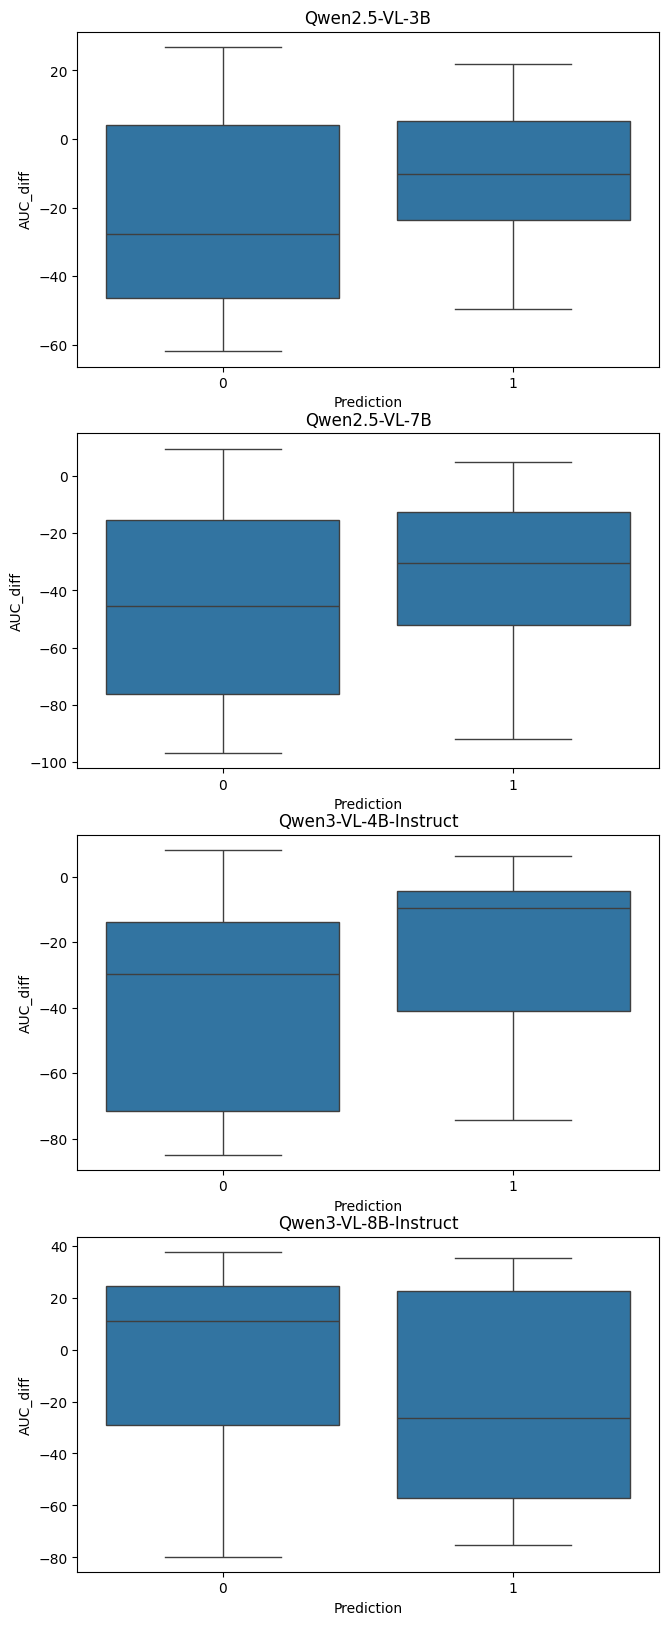

In [5]:
model_name = 'Qwen2.5-VL-3B'
model_ls = [
    'llava-1.5-7b',
    'llava-v1.6-vicuna-7b', 
    'llava-v1.6-mistral-7b', 
    'molmoD-7B',
    'Qwen2.5-VL-3B', 
    'Qwen2.5-VL-7B',
    'Qwen3-VL-4B-Instruct',
    'Qwen3-VL-8B-Instruct',
]

ds_names = [
    # 'MATE',
    'ScienceQA',
    'MicroVQA',
    'MathVision',
    'HallusionBench',
    'BLINK',
    # 'VstarBench'
]

fig, axes = plt.subplots(nrows=len(model_ls), ncols=1, figsize=(7.5, 20))
axes = axes.flatten()

for idx, model_name in enumerate(model_ls):
    plot_df = []
    for ds_name in ds_names:
        if ds_name=='HallusionBench' and model_name=='Qwen2.5-VL-3B':
            pass
        else:
            current_dir = '/exports/csce/eddie/inf/groups/ajitha_project/piyush/MALT/MALT/'
            
            # read dataset
            df = pd.read_csv(f'{current_dir}/results/{model_name}/svd/{ds_name}_svd_effective_rank_corrected.csv')
            
            # create prediction correct or not column
            df['verdict'] = [1 if i==j else 0 for i,j in zip(df['predictionwImg'],df['gold_referencewImg'])]
            
            # AUC columns
            embedding_cols = [c for c in df.columns if c.isdigit()]
            df['AUC'] = [
                sklearn.metrics.auc(
                    # np.arange(len(embedding_cols)),
                    np.arange(len(embedding_cols))/len(embedding_cols),
                    df[embedding_cols].iloc[i].to_numpy()
                )
                for i in range(len(df))
            ]
            
            # plot x and y
            x = df[df['Mean over']=='Text tokens']['verdict'].to_numpy()
            y = df[df['Mean over']=='Text tokens']['AUC'].to_numpy() - df[df['Mean over']=='Img tokens']['AUC'].to_numpy()
            hue = df[df['Mean over']=='Text tokens']['tagwImg'].to_list()
            plot_df_ds = pd.DataFrame({
                'Prediction':x,
                'AUC_diff':y,
                'hue': hue,
                'model': [model_name]*len(x),
                'ds': [ds_name]*len(x)
            })
            
            plot_df = plot_df + [plot_df_ds]
            
    plot_df = pd.concat(plot_df)
    
    b = sns.boxplot(
        data=plot_df,
        x='Prediction',
        y='AUC_diff',
        # hue='Prediction',
        ax=axes[idx],
    )

    b.set_title(model_name)

0 -5
1 -10
2 -15
3 -20
4 0


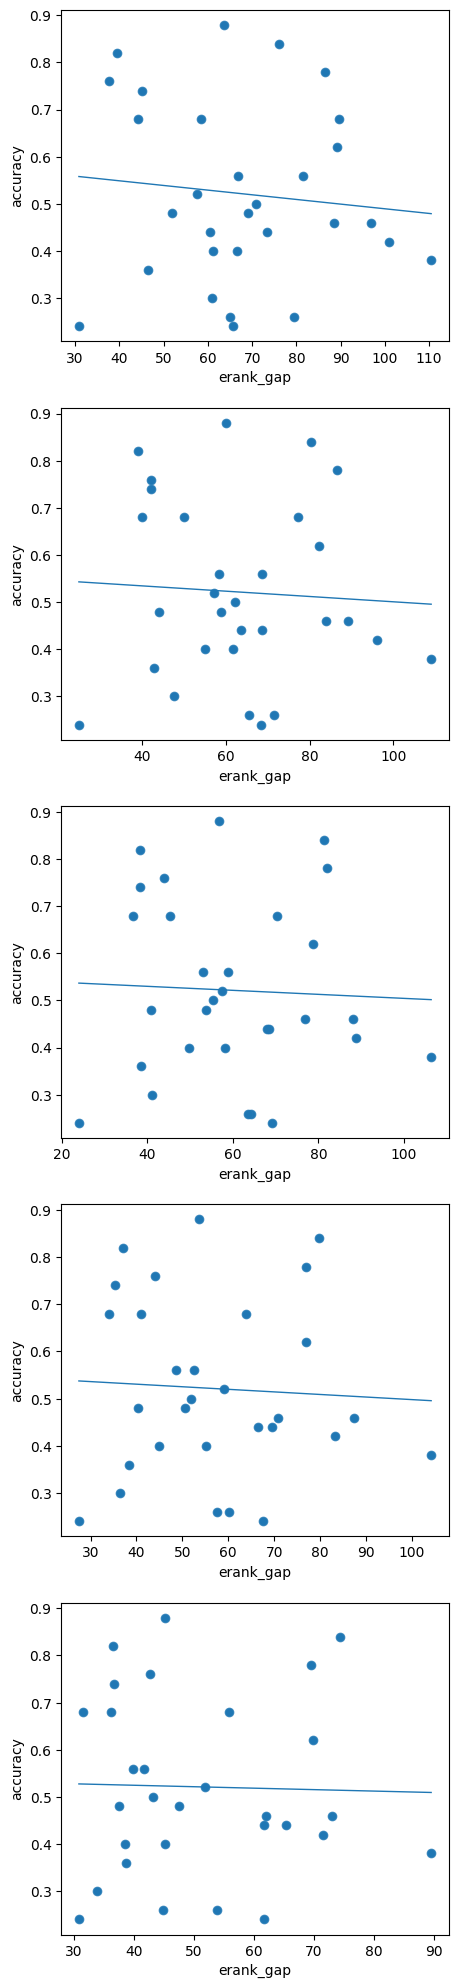

In [7]:

model_ls = [
    # 'llava-1.5-7b',
    'llava-v1.6-vicuna-7b', 
    'llava-v1.6-mistral-7b', 
    'molmoD-7B',
    'Qwen2.5-VL-3B', 
    'Qwen2.5-VL-7B',
    'Qwen3-VL-4B-Instruct',
    'Qwen3-VL-8B-Instruct',
]

ds_names = [
    # 'MATE',
    'ScienceQA',
    'MicroVQA',
    'MathVision',
    'HallusionBench',
    'BLINK',
    # 'VstarBench'
]

fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(5, 25))
axes = axes.flatten()

for idx, lastn in enumerate([-5, -10, -15, -20, 0]):
    plot_df = []
    print(idx, lastn)
    for model_name in model_ls:
        for ds_name in ds_names:
            if ds_name=='HallusionBench' and model_name=='Qwen2.5-VL-3B':
                pass
            elif ds_name=='MicroVQA' and model_name=='Qwen3-VL-8B-Instruct':
                pass
            elif ds_name=='MathVision' and 'Qwen' not in model_name: #in ['molmoD-7B', 'llava-v1.6-mistral-7b']:
                pass
            else:
                current_dir = '/exports/csce/eddie/inf/groups/ajitha_project/piyush/MALT/MALT/'
                
                # read dataset
                df = pd.read_csv(f'{current_dir}/results/{model_name}/svd/{ds_name}_svd_effective_rank_corrected.csv')
                
                # create prediction correct or not column
                df['verdict'] = [1 if i==j else 0 for i,j in zip(df['predictionwImg'],df['gold_referencewImg'])]
                embedding_cols = [c for c in df.columns if c.isdigit()]
                embedding_cols = embedding_cols[lastn:]
                
                # plot x and y
                x = [df[df['Mean over']=='Text tokens']['verdict'].to_numpy().sum()/len(df[df['Mean over']=='Text tokens'])]
                # y = [np.linalg.norm(df[df['Mean over']=='Text tokens'][embedding_cols].to_numpy() - df[df['Mean over']=='Img tokens'][embedding_cols].to_numpy())]
                y = np.sum((
                        df[df['Mean over']=='Text tokens'][embedding_cols].to_numpy() - \
                        df[df['Mean over']=='Img tokens'][embedding_cols].to_numpy())**2
                    )/len(embedding_cols*len(df[df['Mean over']=='Text tokens']))
                y = [np.sqrt(y)]
    
                plot_df_ds = pd.DataFrame({
                    'accuracy':x,
                    'erank_gap':y,
                    # 'hue': hue,
                    'model': [model_name]*len(x),
                    'ds': [ds_name]*len(x)
                })
                
                plot_df = plot_df + [plot_df_ds]
            
    plot_df = pd.concat(plot_df)
        
    b = sns.scatterplot(
        data=plot_df,
        y='accuracy',
        x='erank_gap',
        # hue='Prediction',
        ax=axes[idx],
    )
    sns.regplot(data=plot_df, y="accuracy", x="erank_gap", ci=None,
        scatter=True, ax=b, line_kws={"lw":1})
# b.set_title(model_name)

<Axes: xlabel='erank_gap', ylabel='accuracy'>

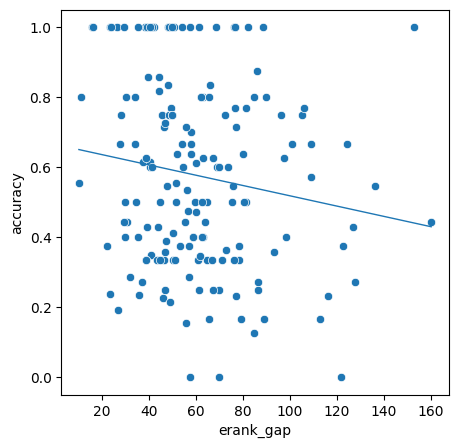

In [9]:

model_ls = [
    # 'llava-1.5-7b',
    'llava-v1.6-vicuna-7b', 
    'llava-v1.6-mistral-7b', 
    'molmoD-7B',
    'Qwen2.5-VL-3B', 
    'Qwen2.5-VL-7B',
    'Qwen3-VL-4B-Instruct',
    'Qwen3-VL-8B-Instruct',
]

ds_names = [
    # 'MATE',
    'ScienceQA',
    'MicroVQA',
    'MathVision',
    'HallusionBench',
    'BLINK',
    # 'VstarBench'
]

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))
# axes = axes.flatten()

plot_df = []
for idx, model_name in enumerate(model_ls):
    for ds_name in ds_names:
        if ds_name=='HallusionBench' and model_name=='Qwen2.5-VL-3B':
            pass
        elif ds_name=='MicroVQA' and model_name=='Qwen3-VL-8B-Instruct':
            pass
        elif ds_name=='MathVision' and 'Qwen' not in model_name: #in ['molmoD-7B', 'llava-v1.6-mistral-7b']:
                pass
        else:
            current_dir = '/exports/csce/eddie/inf/groups/ajitha_project/piyush/MALT/MALT/'
            
            # read dataset
            df = pd.read_csv(f'{current_dir}/results/{model_name}/svd/{ds_name}_svd_effective_rank_corrected.csv')
            
            # create prediction correct or not column
            df['verdict'] = [1 if i==j else 0 for i,j in zip(df['predictionwImg'],df['gold_referencewImg'])]
            embedding_cols = [c for c in df.columns if c.isdigit()][-10:]

            for tg in df['tagwImg'].unique():
                df_ = df[df['tagwImg']==tg]
                # plot x and y
                x = [df_[df_['Mean over']=='Text tokens']['verdict'].to_numpy().sum()/len(df_[df_['Mean over']=='Text tokens'])]
                y = np.sum((
                        df_[df_['Mean over']=='Text tokens'][embedding_cols].to_numpy() - \
                        df_[df_['Mean over']=='Img tokens'][embedding_cols].to_numpy())**2
                    )/len(embedding_cols*len(df_[df_['Mean over']=='Text tokens']))
                y = [np.sqrt(y)]
                # hue = df[df['Mean over']=='Text tokens']['tagwImg'].to_list()
                plot_df_ds = pd.DataFrame({
                    'accuracy':x,
                    'erank_gap':y,
                    'erank_gap_log': np.log(y),
                    # 'hue': hue,
                    'model': [model_name]*len(x),
                    'ds': [ds_name]*len(x)
                })
                
                plot_df = plot_df + [plot_df_ds]
            
plot_df = pd.concat(plot_df)
b = sns.scatterplot(
    data=plot_df,
    y='accuracy',
    x='erank_gap',
    # hue='Prediction',
    ax=axes,
)
sns.regplot(data=plot_df, y="accuracy", x="erank_gap", ci=None,
        scatter=False, ax=b, line_kws={"lw":1})

# b.set_title(model_name)

<Axes: xlabel='variable', ylabel='value'>

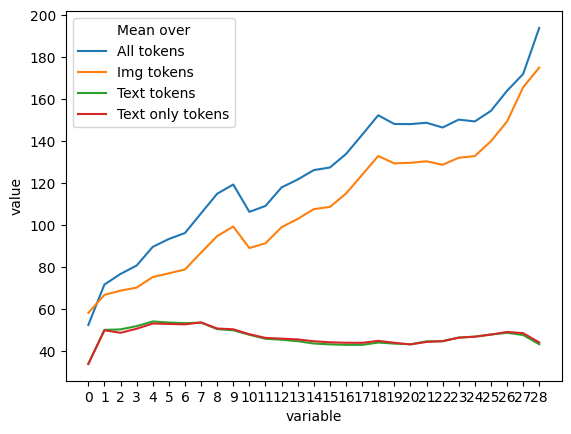

In [38]:

df_ = df[df['idx_corrected']==327]
df_ = df_[embedding_cols+['Mean over']].melt(['Mean over'])

sns.lineplot(
    data=df_,
    x='variable',
    y='value',
    hue='Mean over'
)
